In [1]:
# 必要なライブラリのimport
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Tensorflow
import tensorflow as tf

# データの分割
from sklearn.model_selection import train_test_split

# MSE
from sklearn.metrics import mean_squared_error

# DataFrameで全ての列を表示する設定
pd.options.display.max_columns = None

In [ ]:
# CSVファイルを読み込む。データセットはKaggleの"Wine Type Classification Dataset"を使用
# https://www.kaggle.com/datasets/ehsanesmaeili/red-and-white-wine-quality-merged
dataset_base = pd.read_csv("./wine_quality_merged.csv")
dataset_base.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
# typeをダミー変数に変換
dataset_base = pd.get_dummies(dataset_base, columns=["type"], drop_first=True)
dataset_base.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False


In [ ]:
# quality, type_whiteを除いたデータを説明変数Xに設定
X = dataset_base.drop(columns=["quality", "type_white"])

# 目的変数Yには「白ワインか否か」を指すtype_whiteを設定。合わせてTrue=1, False=0に変換する
Y = dataset_base["type_white"].astype(np.int64)

In [16]:
# データの分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, random_state=0)

In [17]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (3182,) , X_train= (3182, 11)
Y_valid= (1365,) , X_valid= (1365, 11)
Y_test= (1950,) , X_test= (1950, 11)


In [18]:
# モデルの初期化
model = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=(11,)),
    tf.keras.layers.Dense(8, activation='relu'),
    # 隠れ層
    tf.keras.layers.Dense(8, activation='relu'),
    # 出力層
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# モデルの構築
model.compile(optimizer = "rmsprop", loss='binary_crossentropy', metrics=['accuracy'])

In [19]:
# モデルの構造を表示
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177 (708.00 B)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
%%time
# 学習の実施
log = model.fit(X_train, Y_train, epochs=5000, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                            min_delta=0, patience=100,
                                                            verbose=1)],
                validation_data=(X_valid, Y_valid))

Epoch 1/5000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6043 - loss: 1.6642 - val_accuracy: 0.8176 - val_loss: 0.3762
Epoch 2/5000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.9057 - loss: 0.2690 - val_accuracy: 0.9209 - val_loss: 0.2163
Epoch 3/5000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - accuracy: 0.9233 - loss: 0.2234 - val_accuracy: 0.9260 - val_loss: 0.2003
Epoch 4/5000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step - accuracy: 0.9305 - loss: 0.2125 - val_accuracy: 0.9304 - val_loss: 0.1955
Epoch 5/5000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - accuracy: 0.9305 - loss: 0.2095 - val_accuracy: 0.9267 - val_loss: 0.2018
Epoch 6/5000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - accuracy: 0.9331 - loss: 0.2064 - val_accuracy: 0.9304 - val_loss: 0.1950
Epoch 7/5000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.9315 - loss: 0.2057 - val_accuracy: 0.9326 - val_loss: 0.1970
Epoch 8/5000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - accuracy: 0.9337 - l

Text(0, 0.5, 'crossentropy')

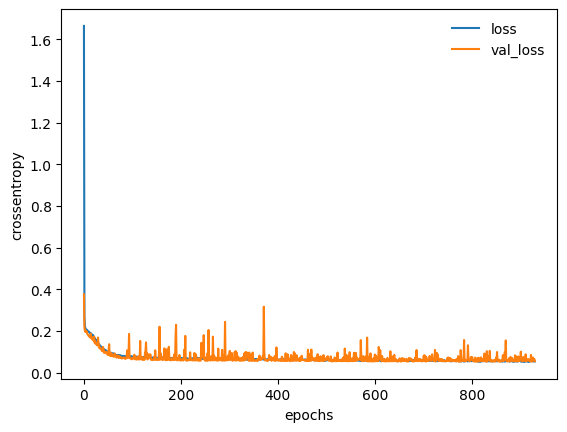

In [21]:
# グラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [22]:
# predictで予測を行なう
Y_pred = model.predict(X_test)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step


In [23]:
# Y_predを表示
Y_pred

array([[0.9973206 ],
       [0.9939626 ],
       [0.99822676],
       ...,
       [0.99287105],
       [0.99892   ],
       [0.9970939 ]], dtype=float32)

In [26]:
# 二値分類は予測結果の確率が0.5以下なら0,
# それより大きければ1となる計算で求める
Y_pred_cls = (Y_pred > 0.5).astype("int32")
Y_pred_cls

array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]], dtype=int32)

In [27]:
# 形状を正解（目的変数）に合わせる
Y_pred_ = Y_pred_cls.reshape(-1)

In [28]:
# モデルの評価
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred_))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       478
           1       0.99      1.00      1.00      1472

    accuracy                           0.99      1950
   macro avg       0.99      0.99      0.99      1950
weighted avg       0.99      0.99      0.99      1950

